\setcounter{secnumdepth}{0}

# Problem Set 5

## FINM 34700
## Om Mehta

## 1. *2-class mini k-NN classification*

### a)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([0.3, 0.5, 0.7])
y = np.array([1, 1, 0])
nn1 = []
for xi in np.arange(0, 1, 0.1):
    min_dist = float('inf')
    idx = -1
    for i in range(3):
        dist = (xi-x[i])**2
        if dist < min_dist:
            min_dist = dist
            idx = y[i]
    nn1.append(idx)

nn1 # i. 1-NN classification

[1, 1, 1, 1, 1, 1, 0, 0, 0, 0]

For $3$-$\mathrm{NN}$ classification, all classifications will **all** be $h(\boldsymbol{x_0})=\frac{1}{3}1 + 1 + 0)\approx0.67$ because $n=k$.

### b)

Text(0, 0.5, 'predicted y (unclassified)')

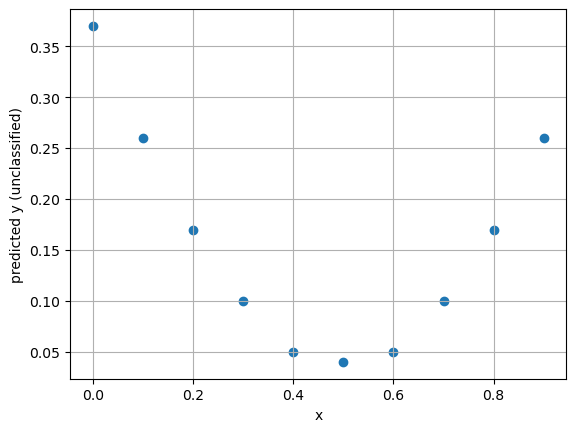

In [3]:
nn2 = []
for xi in np.arange(0, 1, 0.1):
    distances = []
    for i in range(3):
        distances.append((i, (xi-x[i])**2))
    distances = sorted(distances, key=lambda x: x[1])
    output = 0.5 * (distances[2][1]+distances[1][1])
    nn2.append(output)

plt.scatter(np.arange(0, 1, 0.1), nn2)
plt.grid(True)
plt.xlabel('x')
plt.ylabel('predicted y (unclassified)')

## 2. *Classification of two overlapping populations*

### a)

\begin{align*}
f_1(x)=c_1(1-|x-0.5|)\boldsymbol{1}_{\{-0.5\leq x \leq 1.5\}}, \ f_2(x)=c_2(1-|x|)\boldsymbol{1}_{\{-1\leq x \leq 1\}}, \ f_3(x)=c_3(2-|x-0.5|)\boldsymbol{1}_{\{1.5\leq x \leq 2.5\}}
\end{align*}

$$ i=1: $$
\begin{align*}
c_1 \int_{-0.5}^{1.5}(1-|x-0.5|)dx = c_1\left( \int_{-0.5}^{0.5} (0.5+x)dx + \int_{0.5}^{1.5}(1.5-x)dx\right) \\
= c_1 \left( \left[ 0.5x + \frac{x^2}{2} \right]_{-0.5}^{0.5} + \left[ 1.5x - \frac{x^2}{2} \right]_{0.5}^{1.5} \right) \\
\Rightarrow c_1 \cdot [0.5 + 0.5] = 1 \\
\boldsymbol{c_1 = 1}
\end{align*}

$$ i=2: $$
\begin{align*} c_2 \int_{-1}^{1}(1 - |x|)dx = c_2\left( \int_{-1}^{0} (1 + x)dx + \int_{0}^{1}(1 - x)dx\right) \\ = c_2 \left( \left[ x + \frac{x^2}{2} \right]{-1}^{0} + \left[ x - \frac{x^2}{2} \right]{0}^{1} \right) \\ \Rightarrow c_2 \cdot [0.5 + 0.5] = 1 \\ \boldsymbol{c_2 = 1} \end{align*}

$$ i=3: $$
\begin{align*} c_3 \int_{-1.5}^{2.5}(2 - |x - 0.5|)dx = c_3\left( \int_{-1.5}^{0.5} (1.5 + x)dx + \int_{0.5}^{2.5}(2.5 - x)dx\right) \\ = c_3 \left( \left[ 1.5x + \frac{x^2}{2} \right]{-1.5}^{0.5} + \left[ 2.5x - \frac{x^2}{2} \right]{0.5}^{2.5} \right) \\ = c_3 \cdot [2 + 2] = 1 \\ \boldsymbol{c_3 = \frac{1}{4}} \end{align*}

So the final functions are:
$$ f_1(x)=(1-|x-0.5|)\boldsymbol{1}_{\{-0.5 \leq x \leq 1.5 \}} $$
$$ f_2(x)=(1-|x|)\boldsymbol{1}_{\{-1 \leq x \leq 1 \}} $$
$$ f_3(x)=\frac{1}{4}(2-|x-0.5|)\boldsymbol{1}_{\{-1.5 \leq x \leq 2.5 \}} $$

### b)

Since both costs of missclassifications are equal, they cancel out in the inequality for $R_1$ and $R_2$:
$$
\begin{cases}
R_1 = \{\boldsymbol{x}: 0.8f_1(x) \geq 0.2f_2(x)\} \\ \\ 
R_2 = \{\boldsymbol{x}: 0.8f_1(x) < 0.2f_2(x)\}
\end{cases}
$$

$$
\begin{cases}
R_1 = \{\boldsymbol{x}: 4f_1(x) \geq f_2(x)\} \\ \\ 
R_2 = \{\boldsymbol{x}: 4f_1(x) < f_2(x)\}
\end{cases}
$$

### c)

Since both costs of missclassifications are equal, they cancel out in the inequality for $R_1$ and $R_3$:
$$
\begin{cases}
R_1 = \{\boldsymbol{x}: 0.8f_1(x) \geq 0.2f_3(x)\} \\ \\ 
R_3 = \{\boldsymbol{x}: 0.8f_1(x) < 0.2f_3(x)\}
\end{cases}
$$

$$
\begin{cases}
R_1 = \{\boldsymbol{x}: 4f_1(x) \geq f_3(x)\} \\ \\ 
R_3 = \{\boldsymbol{x}: 4f_1(x) < f_3(x)\}
\end{cases}
$$

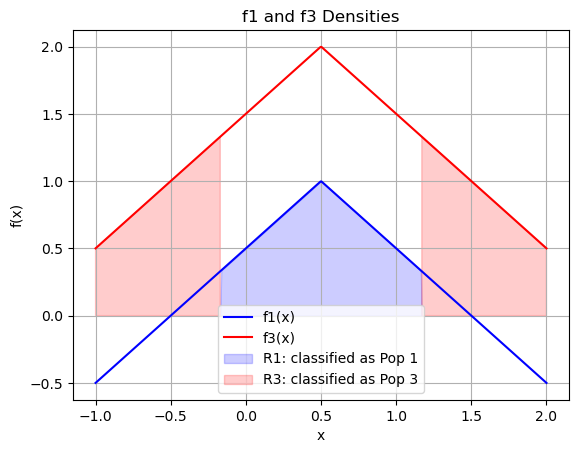

In [4]:
fig, ax = plt.subplots()

x = np.linspace(-1, 2, 500)
y1 = 1 - np.abs(x - 0.5)      
y3 = 2 - np.abs(x - 0.5)      

ax.plot(x, y1, label='f1(x)', color='blue', linestyle='-')
ax.plot(x, y3, label='f3(x)', color='red', linestyle='-')
mask = 4 * y1 >= y3

ax.fill_between(x, 0, y1, where=mask, interpolate=True, color='blue', alpha=0.2, label='R1: classified as Pop 1')
ax.fill_between(x, 0, y3, where=~mask, interpolate=True, color='red', alpha=0.2, label='R3: classified as Pop 3')

ax.set_title("f1 and f3 Densities")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True)

plt.show()

### *3. Fisher's linear discriminants for three classes*

In [5]:
import pandas as pd

### a)

In [6]:
filepath = 'GpaGmat.txt'
df = pd.read_csv(filepath, sep=r'\s+', header=None)
vars = ['GPA', 'GMAT']
df.columns=['GPA', 'GMAT', 'Admit']
x1 = df.loc[df['Admit'] == 1].drop(columns=['Admit'])
x2 = df.loc[df['Admit'] == 2].drop(columns=['Admit'])
x3 = df.loc[df['Admit'] == 3].drop(columns=['Admit'])
display(x1.head(3), x2.head(3), x3.head(3))

,GPA,GMAT
0,2.96,596
1,3.14,473
2,3.22,482


,GPA,GMAT
31,2.54,446
32,2.43,425
33,2.20,474


,GPA,GMAT
59,2.86,494
60,2.85,496
61,3.14,419


In [7]:
xbar1, xbar2, xbar3 = [np.array(np.mean(x, axis=0)) for x in [x1, x2, x3]]
W = np.vstack([xbar1, xbar2, xbar3])
n1, n2, n3 = len(x1), len(x2), len(x3)
xbar_total = (n1*xbar1 + n2*xbar2 + n3*xbar3)/(n1+n2+n3)

$\bar{\boldsymbol{x}}_i$ and $\bar{\boldsymbol{x}}$:

In [8]:
pd.DataFrame(np.vstack([W, xbar_total]), index=[1, 2, 3, 'Total'], columns=vars)

,GPA,GMAT
1,3.403871,561.225806
2,2.482500,447.071429
3,2.992692,446.230769
Total,2.974588,488.447059


$\boldsymbol{S}_{pool}$:

In [9]:
s1, s2, s3 = [np.cov(x, rowvar=False) for x in [x1, x2, x3]]
S_pool = (1/(n1+n2+n3 - 3)) * sum([(n1-1)*s1, (n2-1)*s2, (n3-1)*s3])
pd.DataFrame(S_pool, index=vars, columns=vars)

,GPA,GMAT
GPA,0.036068,-2.018759
GMAT,-2.018759,3655.901121


### b)

In [10]:
def sscp(X, xbar):
    centered = X-xbar
    return centered.T @ centered
    
def sscp_B(X, T):
    diff = (X-T).reshape(-1, 1)
    return diff @ diff.T

In [11]:
# Within group sum of squares
W = sscp(x1, xbar1) + sscp(x2, xbar2) + sscp(x3, xbar3)
W_inv = np.linalg.inv(W)

# Between group sum of squares
B = n1*sscp_B(xbar1, xbar_total) + n2*sscp_B(xbar2, xbar_total) + n3*sscp_B(xbar3, xbar_total)

W_inv_B = W_inv @ B

In [12]:
lambdas, A = np.linalg.eig(W_inv_B)
display(pd.DataFrame(lambdas.T, index=['Lambda 1', 'Lambda 2']), pd.DataFrame(A.T, columns=['a1', 'a2'])) 

,0
Lambda 1,5.646045
Lambda 2,0.190611


,a1,a2
0,0.999999,0.001711
1,-0.999970,0.007700


### c)

In [13]:
z1 = A.T @ xbar1
z2 = A.T @ xbar2
z3 = A.T @ xbar3

In [14]:
class Classifier:
    def __init__(self, x):
        self.x = x
        self.z = A.T @ self.x
        self.d1 = np.linalg.norm(self.z - z1)
        self.d2 = np.linalg.norm(self.z - z2)
        self.d3 = np.linalg.norm(self.z - z3)
    def classify(self):
        min = float('inf')
        min_idx = 0
        for i, d in enumerate([self.d1, self.d2, self.d3]):
            if d < min:
                min = d
                min_idx = i+1
        return min_idx

In [15]:
x1 = np.array([3.21, 497]).reshape(-1, 1)
x2 = np.array([3.22, 497]).reshape(-1, 1)
x1_c = Classifier(x1)
x2_c = Classifier(x2)
g1, g2 = x1_c.classify(), x2_c.classify()
g1, g2

(2, 2)

Using Fisher's Linear Discriminant for 3 classes, both observations fall in the **not admitted** category.

### d)

In [16]:
x1_c.z, x2_c.z

(array([[4.06022152],
        [0.61704247]]),
 array([[4.0702215 ],
        [0.60704276]]))

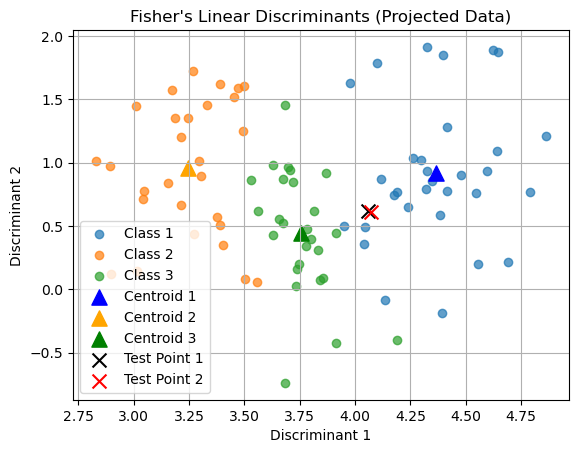

In [17]:
X = df.drop(columns=['Admit']).values
X_proj = (A.T @ X.T).T

labels = df['Admit'].values

for i, label in enumerate([1, 2, 3]):
    plt.scatter(X_proj[labels == label, 0],
                X_proj[labels == label, 1],
                label=f'Class {label}', alpha=0.7)

plt.scatter(*z1, marker='^', color='blue', s=120, label='Centroid 1')
plt.scatter(*z2, marker='^', color='orange', s=120, label='Centroid 2')
plt.scatter(*z3, marker='^', color='green', s=120, label='Centroid 3')
plt.scatter(*x1_c.z, color='black', marker='x', s=100, label='Test Point 1')
plt.scatter(*x2_c.z, color='red', marker='x', s=100, label='Test Point 2')


plt.legend()
plt.grid(True)
plt.xlabel('Discriminant 1')
plt.ylabel('Discriminant 2')
plt.title("Fisher's Linear Discriminants (Projected Data)")
plt.show()

Although the scatter-plot makes the two test observations look closer to the “Yes” (class 1) and “Borderline” (class 3) clouds, the Fisher-LDA rule assigns them to “No” (class 2).
The apparent mismatch is purely visual:
* **Metric mismatch**: Our eyes judge ordinary Euclidean distance on the plotted axes, but the classifier measures distance in the $\Sigma_W^{-1}$ (Mahalanobis) metric embedded in Fisher's discriminant scores.
* **Dominant axis**: Over $99\%$ of the between-class separation lies on the first discriminant. Small horizontal shifts therefore outweigh larger vertical ones in the decision rule, even though the axes are drawn with equal scales.
* **Scale effect**: GMAT values vary by ~$150$ points whereas GPA varies by ~$1.5$; that raw scale difference, preserved in $\Sigma_W$, drags both test points toward the “No” centroid once the correct metric is applied.

So—mathematically and conceptually the points belong to group 2; the 2-D picture just isn’t drawn in the same geometry the classifier uses.

## *4. Hands-on classifications for two normal populations*

In [18]:
X1 = np.array([[3, 7],
              [2, 4],
              [4, 7]]
             )

X2 = np.array([[6, 9],
              [5, 7],
              [4, 8]]
             )

mu1 = np.mean(X1, axis=0)
mu2 = np.mean(X2, axis=0)
S1 = np.cov(X1, rowvar=False)
S2 = np.cov(X2, rowvar=False)

In [19]:
n = 3
S_pool = 1/(2*n - 2) + sum([(n-1)*S1, (n-2)*S2])
S_pool

array([[3.25, 3.75],
       [3.75, 7.25]])

In [20]:
X = np.vstack([X1, X2])
y = (mu1-mu2) @ np.linalg.inv(S_pool) @ X.T
y # Estimated linear discriminant function

array([-1.47368421, -1.05263158, -2.21052632, -3.47368421, -2.94736842,
       -2.10526316])

### b)

**Using the formula:**
$$
(\bar{\boldsymbol{x}_1} - \bar{\boldsymbol{x}_2})'\boldsymbol{S}_{pool}^{-1}\boldsymbol{x}_0-\frac{1}{2}(\bar{\boldsymbol{x}_1} - \bar{\boldsymbol{x}_2})'\boldsymbol{S}_{pool}^{-1}(\bar{\boldsymbol{x}_1} + \bar{\boldsymbol{x}_2}) \geq 0
$$
We set the right hand side to $0$ because with equal costs and priors, the term squeezes down to $ln(1)=0$.

In [21]:
x1 = np.array([4.1, 5]).reshape(-1, 1)
x2 = np.array([3.9, 9]).reshape(-1, 1)
def classify(x):
    return (mu1-mu2) @ np.linalg.inv(S_pool) @ x - 0.5*(mu1-mu2) @ np.linalg.inv(S_pool) @ (mu1+mu2)
class_1 = 1 if classify(x1) >= 0 else 2
class_2 = 1 if classify(x2) >= 0 else 2
class_1, class_2

(2, 1)

With **equal costs and priors**, we assign the first observation to group 2, and the second to group 1.

### c)

We now set the right hand side of the equation to:
$$
ln \left( \frac{c(1|2)}{c(2|1)} \cdot \frac{p_2}{p_1} \right) = ln \left( \frac{20}{3} \cdot \frac{0.9}{0.1} \right) = ln(60) \approx 4.094
$$

In [22]:
class_1 = 1 if classify(x1) >= 4.094 else 2
class_2 = 1 if classify(x2) >= 4.094 else 2
class_1, class_2

(2, 2)

With **costs $\$3$ and $\$20$** and **priors $10\%$ and $90\%$**, both observations fell in group 2.

### d)

In [23]:
def d(x):
    invS1 = np.linalg.inv(S1)
    invS2 = np.linalg.inv(S2)
    
    term1 = -0.5 * (x.T @ (invS1 - invS2) @ x)                      # scalar
    term2 = (mu1.T @ invS1 - mu2.T @ invS2) @ x                     # scalar
    k_hat = 0.5 * (mu1.T @ invS1 @ mu1 - mu2.T @ invS2 @ mu2) + 0.5 * np.log(np.linalg.det(S1) / np.linalg.det(S2))  # scalar
    
    return term1 + term2 - k_hat

In [24]:
class_1 = 1 if d(x1) >= 0 else 2
class_2 = 2 if d(x2) >= 0 else 2
class_1, class_2

(2, 2)

With **unequal covariances and equal costs and priors**, both groups **still got classified to group 2**.

### e)

The only difference in classification was the second observation $\boldsymbol{x} = [3.9 \ 9]'$, going from group 1 to group 2. When covariances are **assumed equal** (LDA), the math only cares about how far the datapoints are from the means, not about the shape of the distribution. But in reality, **group 2 had a larger spread in the direction of $\boldsymbol{x}$**, so under QDA, we can say "x is more likely to belong to group 2 because group 2 'tolerates' higher variance in that direction." Mathematically, it's due to the **quadratic term** $-\frac{1}{2}\boldsymbol{x}_0'(\boldsymbol{S}_1^{-1} - \boldsymbol{S}_2^{-1})\boldsymbol{x}_0$. This makes the decision boundary become nonlinear.

### f)

Hotelling's $T^2$ statistic is given by: 
$$ 
\frac{n_1n_2}{n_1+n_2}(\bar{\mathrm{x}}_1 - \bar{\mathrm{x}}_2)^\top S_{\text{pool}}^{-1}(\bar{\mathrm{x}}_1 - \bar{\mathrm{x}}_2)
$$

In [25]:
n = 3
T2 = (n**2/2*n)*(mu1-mu2).T @ np.linalg.inv(S_pool) @ (mu1-mu2)

In [26]:
from scipy.stats import f

In [27]:
p = 2
F = ((2 * n - p - 1) / p*(2 * n - 2)) * T2
df1 = p
df2 = 2*n-p-1
p = 1-f.cdf(F, df1, df2)
p

0.0017367678542693499

Strong evidence **against equal mean vectors.**

## *5. Graphical exercise on linear discriminants and conceptual SVM*

In [28]:
Xi1, Yi1 = (X1[:, :-1]).reshape(1, -1), (X1[:, 1:]).reshape(1, -1)
Xi2, Yi2 = (X2[:, :-1]).reshape(1, -1), (X2[:, 1:]).reshape(1, -1)

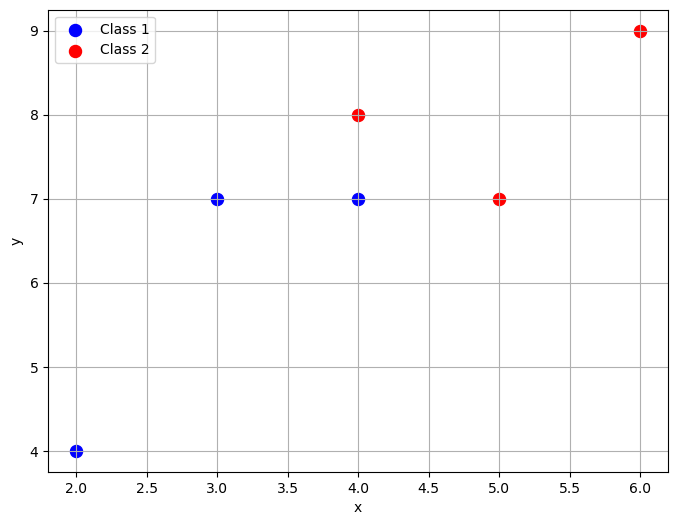

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(Xi1, Yi1, color='blue', label='Class 1', marker='o', s=75)
plt.scatter(Xi2, Yi2, color='red', label='Class 2', marker='o', s=75)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

### a)

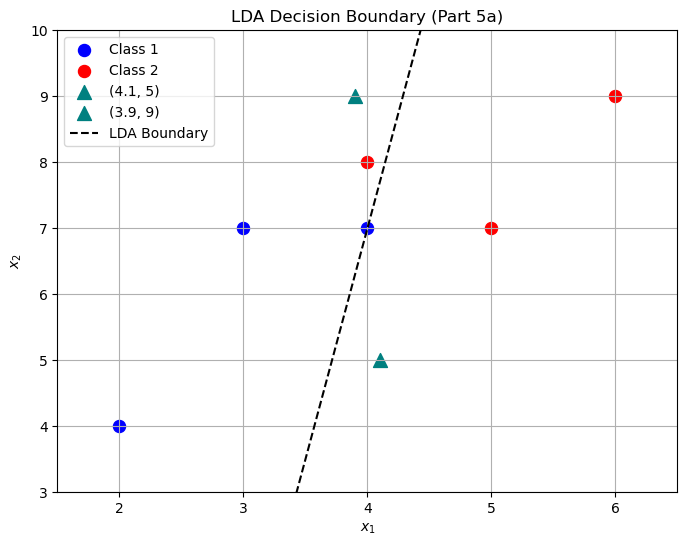

In [30]:
S_inv = np.linalg.inv(S_pool)
w = (mu1 - mu2) @ S_inv
m_hat = 0.5 * (mu1 + mu2) @ S_inv @ (mu1 - mu2)

x_vals = np.linspace(1.5, 6.5, 100)

y_vals = (m_hat - w[0] * x_vals) / w[1]

plt.figure(figsize=(8, 6))

plt.scatter(Xi1, Yi1, color='blue', label='Class 1', marker='o', s=75)
plt.scatter(Xi2, Yi2, color='red', label='Class 2', marker='o', s=75)

plt.scatter(4.1, 5, color='teal', marker='^', s=100, label='(4.1, 5)')
plt.scatter(3.9, 9, color='teal', marker='^', s=100, label='(3.9, 9)')

plt.plot(x_vals, y_vals, 'k--', label='LDA Boundary')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('LDA Decision Boundary (Part 5a)')
plt.legend()
plt.grid(True)
plt.xlim(1.5, 6.5)
plt.ylim(3, 10)
plt.show()

### b)

Solely from eyeballing, I felt that **the hard SVM decision boundary** would look something like the line $y=-0.9x+11$.

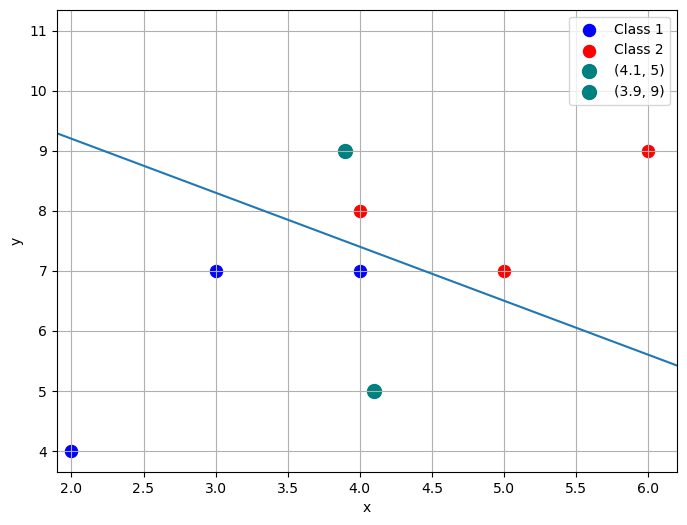

In [31]:
xvals = np.arange(0, 8, 0.5)
plt.figure(figsize=(8, 6))
plt.scatter(Xi1, Yi1, color='blue', label='Class 1', marker='o', s=75)
plt.scatter(Xi2, Yi2, color='red', label='Class 2', marker='o', s=75)
plt.scatter(4.1, 5, color='teal', marker='o', s=100, label='(4.1, 5)')
plt.scatter(3.9, 9, color='teal', marker='o', s=100, label='(3.9, 9)')
plt.plot(xvals, (-0.9*xvals + 11))
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.xlim(1.9, 6.2)
plt.legend()
plt.show()

The **support vectors** (just points in this case) are $[4 \ 7]'$ and $[5 \ 7]'$.
Adding the new points, we see that $(4.1, 5)$ lies in class 1 and $(3.9, 9)$ lies in class 2. 

### c)

I prefer the **SVM** (solely based on visual examination, it looks like it separates the data more clearly), but in higher-dimensional cases with more observations, LDA might fit better due to its ability to account for variability in the data. 

### d)

In [32]:
# --- QDA discriminant function ---
def d(x):
    x = x.reshape(-1, 1)  # Ensure column vector shape (2,1)

    invS1 = np.linalg.inv(S1)
    invS2 = np.linalg.inv(S2)

    # Quadratic term
    term1 = -0.5 * (x.T @ (invS1 - invS2) @ x).item()

    # Linear term
    term2 = ((mu1.T @ invS1) - (mu2.T @ invS2)) @ x
    term2 = term2.item()

    # Constant offset
    k_hat = 0.5 * (mu1.T @ invS1 @ mu1 - mu2.T @ invS2 @ mu2).item()
    k_hat += 0.5 * np.log(np.linalg.det(S1) / np.linalg.det(S2))

    return term1 + term2 - k_hat

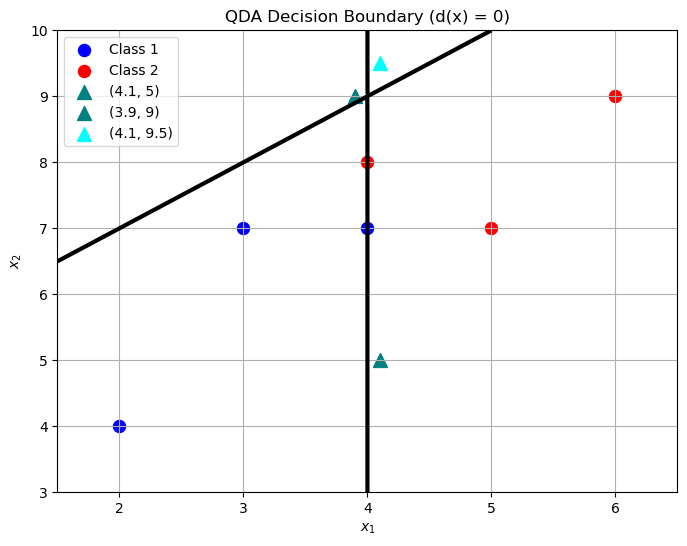

In [46]:
x1_vals = np.linspace(1.5, 6.5, 300)
x2_vals = np.linspace(3, 10, 300)
xx1, xx2 = np.meshgrid(x1_vals, x2_vals)

z = np.array([
    d(np.array([x, y]))
    for x, y in zip(xx1.ravel(), xx2.ravel())
]).reshape(xx1.shape)

plt.figure(figsize=(8, 6))

plt.scatter(Xi1, Yi1, color='blue', label='Class 1', s=75)
plt.scatter(Xi2, Yi2, color='red', label='Class 2', s=75)
plt.scatter(4.1, 5, color='teal', marker='^', s=100, label='(4.1, 5)')
plt.scatter(3.9, 9, color='teal', marker='^', s=100, label='(3.9, 9)')
plt.scatter(4.1, 9.5, color='cyan', marker='^', s=100, label='(4.1, 9.5)')

plt.contour(xx1, xx2, z, levels=[0], colors='black', linestyles='-', linewidths=3)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('QDA Decision Boundary (d(x) = 0)')
plt.grid(True)
plt.legend()
plt.xlim(1.5, 6.5)
plt.ylim(3, 10)
plt.show()

In [45]:
# is the QDA a hyperbola?

A = np.linalg.inv(S1) - np.linalg.inv(S2)
print(np.linalg.eigvals(A))

[ 3.21895142 -0.55228475]


In [47]:
print("Point (4.1, 5):", d(np.array([4.1, 5])))       # Lower region
print("Point (3.9, 9):", d(np.array([3.9, 9])))       # Upper left
print("Point (4.1, 9.5):", d(np.array([4.1, 9.5])))   # Upper right

Point (4.1, 5): -0.5466666666666704
Point (3.9, 9): -0.01333333333332476
Point (4.1, 9.5): 0.05333333333333812


ii. Both points $(4.1, 5)$ and $(3.9, 9)$ were classified into class 2.

iii. The point $(4.1, 9.5)$ was classified into class 1. Its distance is *very* close to 0, but it is reasonable given that we are dealing with a hyperbolic structure of the QDA boundary.

The quadratic rule here **is not** better than the LDC in part $(\text{a})$ because the data are so small and the class covariance matrices are not meaningfully different. As a result, the QDA boundary reduces to a degenerate conic — essentially a pair of nearly linear segments — which does not offer a significant improvement over the linear separator found by LDA. In fact, QDA may introduce unnecessary complexity and ambiguity in visualization, as its decision regions become harder to interpret when the curvature is minimal. With such limited data, the added flexibility of QDA doesn’t improve classification performance and may even hinder interpretability.